### Social Media Data Analysis

In [49]:
# ===========
# IMPORTS
# ==========

# Data Handling
import pandas as pd 
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt 
import seaborn as sns 

%matplotlib inline

In [2]:
# ===============
# LOAD DATASET
# ==============

df = pd.read_csv('Social Media Engagement Dataset.csv')
df.head()

,post_id,timestamp,day_of_week,platform,user_id,location,language,text_content,hashtags,mentions,...,comments_count,impressions,engagement_rate,brand_name,product_name,campaign_name,campaign_phase,user_past_sentiment_avg,user_engagement_growth,buzz_change_rate
0,kcqbs6hxybia,2024-12-09 11:26:15,Monday,Instagram,user_52nwb0a6,"Melbourne, Australia",pt,Just tried the Chromebook from Google. Best pu...,#Food,NaN,...,701,18991,0.19319,Google,Chromebook,BlackFriday,Launch,0.0953,-0.3672,19.1
1,vkmervg4ioos,2024-07-28 19:59:26,Sunday,Twitter,user_ucryct98,"Tokyo, Japan",ru,Just saw an ad for Microsoft Surface Laptop du...,"#MustHave, #Food","@CustomerService, @BrandCEO",...,359,52764,0.05086,Microsoft,Surface Laptop,PowerRelease,Post-Launch,0.1369,-0.4510,-42.6
2,memhx4o1x6yu,2024-11-23 14:00:12,Saturday,Reddit,user_7rrev126,"Beijing, China",ru,What's your opinion about Nike's Epic React? ...,"#Promo, #Food, #Trending",NaN,...,643,8887,0.45425,Nike,Epic React,BlackFriday,Post-Launch,0.2855,-0.4112,17.4
3,bhyo6piijqt9,2024-09-16 04:35:25,Monday,YouTube,user_4mxuq0ax,"Lagos, Nigeria",en,Bummed out with my new Diet Pepsi from Pepsi! ...,"#Reviews, #Sustainable","@StyleGuide, @BrandSupport",...,743,6696,0.42293,Pepsi,Diet Pepsi,LaunchWave,Launch,-0.2094,-0.0167,-5.5
4,c9dkiomowakt,2024-09-05 21:03:01,Thursday,Twitter,user_l1vpox2k,"Berlin, Germany",hi,Just tried the Corolla from Toyota. Absolutely...,"#Health, #Travel","@BrandSupport, @InfluencerName",...,703,47315,0.08773,Toyota,Corolla,LocalTouchpoints,Launch,0.6867,0.0807,38.8


### Data Inspection

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 28 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   post_id                  12000 non-null  object 
 1   timestamp                12000 non-null  object 
 2   day_of_week              12000 non-null  object 
 3   platform                 12000 non-null  object 
 4   user_id                  12000 non-null  object 
 5   location                 12000 non-null  object 
 6   language                 12000 non-null  object 
 7   text_content             12000 non-null  object 
 8   hashtags                 12000 non-null  object 
 9   mentions                 8059 non-null   object 
 10  keywords                 12000 non-null  object 
 11  topic_category           12000 non-null  object 
 12  sentiment_score          12000 non-null  float64
 13  sentiment_label          12000 non-null  object 
 14  emotion_type          

In [4]:
df.describe()

,sentiment_score,toxicity_score,likes_count,shares_count,comments_count,impressions,engagement_rate,user_past_sentiment_avg,user_engagement_growth,buzz_change_rate
count,12000.000000,12000.000000,12000.00000,12000.000000,12000.00000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000
mean,0.000553,0.503868,2490.72025,1007.167167,504.34575,49811.338500,0.278137,0.001472,0.000998,0.729692
std,0.583563,0.288198,1441.53253,575.072282,288.68416,28930.289451,1.149206,0.576627,0.289940,57.787219
min,-0.999800,0.000000,0.00000,0.000000,0.00000,130.000000,0.001880,-0.999600,-0.499900,-99.900000
25%,-0.503200,0.251400,1236.00000,510.000000,253.00000,24716.500000,0.049100,-0.495975,-0.248400,-48.700000
50%,-0.006200,0.505950,2496.00000,1018.000000,503.00000,49674.000000,0.080605,0.001950,0.002800,0.900000
75%,0.513525,0.756200,3723.25000,1501.000000,755.00000,74815.000000,0.163123,0.501725,0.250700,50.100000
max,0.999900,0.999900,5000.00000,2000.000000,1000.00000,99997.000000,32.211710,0.999400,0.499900,99.900000


In [5]:
missing_values = df.isnull().sum().sort_values(ascending=False)
missing_values

mentions                   3941
post_id                       0
day_of_week                   0
timestamp                     0
platform                      0
user_id                       0
language                      0
location                      0
text_content                  0
hashtags                      0
keywords                      0
topic_category                0
sentiment_score               0
sentiment_label               0
emotion_type                  0
toxicity_score                0
likes_count                   0
shares_count                  0
comments_count                0
impressions                   0
engagement_rate               0
brand_name                    0
product_name                  0
campaign_name                 0
campaign_phase                0
user_past_sentiment_avg       0
user_engagement_growth        0
buzz_change_rate              0
dtype: int64

### Data Cleaning

In [6]:
# Drop Unncessary Columns

df = df.drop(columns=['user_id','language','location','text_content', 'hashtags','keywords','topic_category','sentiment_score',
                      'sentiment_label' , 'emotion_type' ,'toxicity_score', 'brand_name', 'product_name','campaign_name',  
                      'campaign_phase','user_past_sentiment_avg','user_engagement_growth','buzz_change_rate'])

In [7]:
df.drop('mentions',axis=1,inplace=True)

In [8]:
df.head()

,post_id,timestamp,day_of_week,platform,likes_count,shares_count,comments_count,impressions,engagement_rate
0,kcqbs6hxybia,2024-12-09 11:26:15,Monday,Instagram,1264,1704,701,18991,0.19319
1,vkmervg4ioos,2024-07-28 19:59:26,Sunday,Twitter,522,1803,359,52764,0.05086
2,memhx4o1x6yu,2024-11-23 14:00:12,Saturday,Reddit,2689,705,643,8887,0.45425
3,bhyo6piijqt9,2024-09-16 04:35:25,Monday,YouTube,1827,262,743,6696,0.42293
4,c9dkiomowakt,2024-09-05 21:03:01,Thursday,Twitter,2005,1443,703,47315,0.08773


In [9]:
# Checking Missing Values

missing_values = df.isnull().sum().sort_values(ascending=False)
missing_values

post_id            0
timestamp          0
day_of_week        0
platform           0
likes_count        0
shares_count       0
comments_count     0
impressions        0
engagement_rate    0
dtype: int64

In [10]:
# Convert 'timestamp' to Datetime

df['timestamp'] = pd.to_datetime(df['timestamp'])

In [11]:
df['timestamp'].dtype

dtype('<M8[ns]')

In [12]:
# New Feature 'total_engagment' from likes_count,shares_count, and comments_count

df['total_engagment'] = df['likes_count'] + df['shares_count'] + df['comments_count']

In [13]:
df.head()

,post_id,timestamp,day_of_week,platform,likes_count,shares_count,comments_count,impressions,engagement_rate,total_engagment
0,kcqbs6hxybia,2024-12-09 11:26:15,Monday,Instagram,1264,1704,701,18991,0.19319,3669
1,vkmervg4ioos,2024-07-28 19:59:26,Sunday,Twitter,522,1803,359,52764,0.05086,2684
2,memhx4o1x6yu,2024-11-23 14:00:12,Saturday,Reddit,2689,705,643,8887,0.45425,4037
3,bhyo6piijqt9,2024-09-16 04:35:25,Monday,YouTube,1827,262,743,6696,0.42293,2832
4,c9dkiomowakt,2024-09-05 21:03:01,Thursday,Twitter,2005,1443,703,47315,0.08773,4151


### Quick EDA 

In [14]:
# Generate Quick EDA for Understnding Data 
# Generate in html format 

from ydata_profiling import ProfileReport 
profile = ProfileReport(df)
profile.to_file('eda_report.html')

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


%|                                                                                           | 0/10 [00:00<?, ?it/s]
%|████████▎                                                                          | 1/10 [00:00<00:02,  4.32it/s]
100%|██████████████████████████████████████████████████████████████████████████████████| 10/10 [00:00<00:00, 28.57it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

### Platform Performance Analysis (Business Value)

Highest Average Engagement-Rate Platform:  Instagram


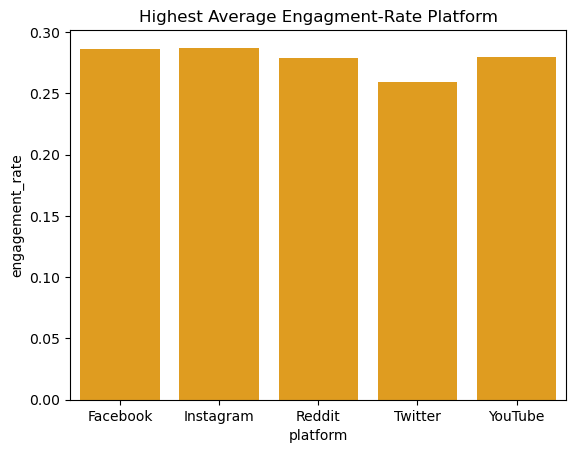

In [26]:
#  Which platform generates the **highest average engagement rate**?

platform_engagment = df.groupby('platform')['engagement_rate'].mean()
max_platform = platform_engagment.idxmax()
print('Highest Average Engagement-Rate Platform: ', max_platform)
pf_eng_df = platform_engagment.reset_index()

sns.barplot(data=pf_eng_df,x='platform',y='engagement_rate',color='orange')
plt.title('Highest Average Engagment-Rate Platform')
plt.show()

Instagram shows the highest engagement rate, indicating stronger audience interaction compared to other platforms.

Platform With Highest Total Engagement: YouTube


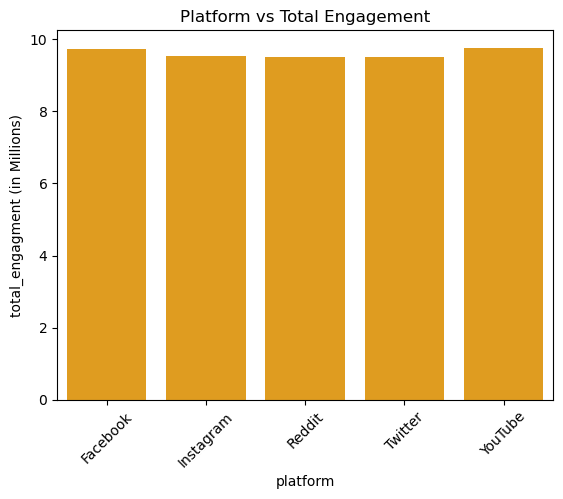

In [56]:
# Which platform have Highest Total Engagement?

total_eng = df.groupby('platform')['total_engagment'].sum()
highest = total_eng.idxmax() # return the highest total engagement platform name 
print('Platform With Highest Total Engagement:', highest)

platform_df = total_eng.reset_index()
platform_df['total_engagment (in Millions)'] = platform_df['total_engagment'] / 1_000_000
# visualize it 
sns.barplot(data=platform_df, x='platform', y='total_engagment (in Millions)',color='orange')
plt.title('Platform vs Total Engagement')
plt.xticks(rotation=45)
plt.show()

YouTube drives the most shares (virality) with ~2.48 million shares, making it the top-performing platform.
YouTube is the most effective platform for driving shares (virality), with the highest total share count.

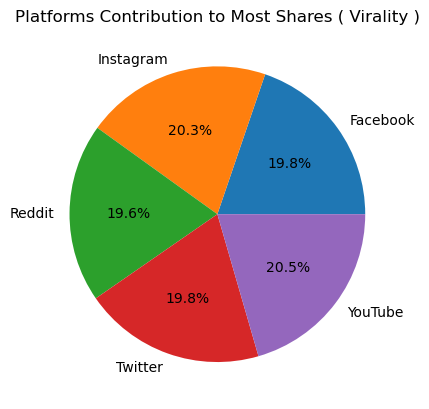

In [55]:
# Which platform Contributes most shares (virality) ?

most_shares = df.groupby('platform')['shares_count'].sum()
# visualization
plt.pie(most_shares,labels=most_shares.index,autopct='%1.1f%%')
plt.title('Platforms Contribution to Most Shares ( Virality )')
plt.show()

### Engagement-Based Analysis 

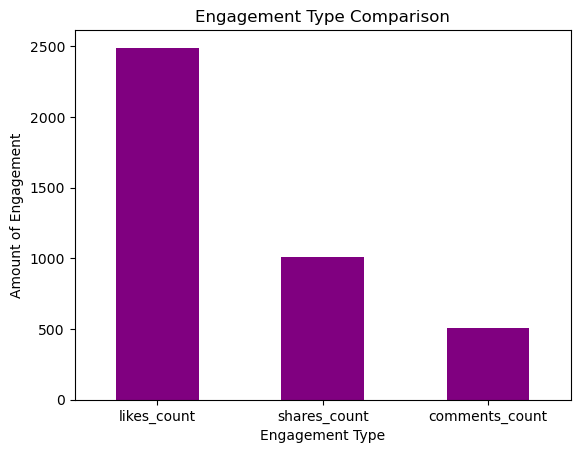

In [64]:
# Engagement Type Comparison

engagement_type = df[['likes_count','shares_count','comments_count']].mean()
# bar plot for comparison
engagement_type.plot(kind='bar',color='purple')
plt.title('Engagement Type Comparison')
plt.xlabel('Engagement Type')
plt.ylabel('Amount of Engagement')
plt.xticks(rotation=0)
plt.show()

Users Prefer likes on posts more than sharing or comment 

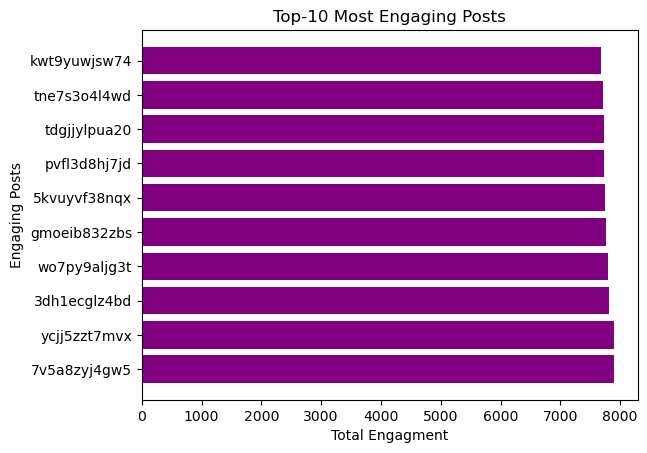

In [93]:
#  Top 10 Most Engaging Posts

top_10 = df.sort_values(by='total_engagment',ascending=False).head(10)
plt.barh(top_10['post_id'],top_10['total_engagment'],color='purple')
plt.title('Top-10 Most Engaging Posts')
plt.xlabel('Total Engagment')
plt.ylabel('Engaging Posts')
plt.show()

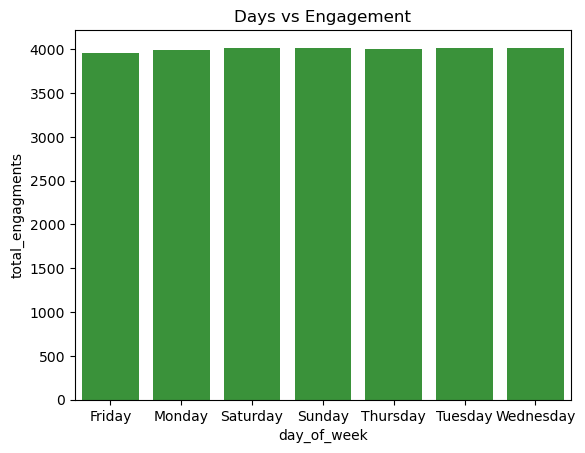

In [95]:
# Which day gets Highest Engagment 

engagment_day = df.groupby('day_of_week')['total_engagment'].mean()
sort_df = engagment_day.reset_index()

sort_df['total_engagments'] = sort_df['total_engagment'] / 1
# barplot 
sns.barplot(data=sort_df,x='day_of_week',y='total_engagments',color='#2CA02C')
plt.title('Days vs Engagement')
plt.show()

### Social Media Interaction breakdown 
#### likes , Shares and Comments Analysis 

C:\Users\Admin\AppData\Local\Temp\ipykernel_57912\3606477328.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(['Mon','Tue','Wed','Thu','Fri','Sat','Sun'])
C:\Users\Admin\AppData\Local\Temp\ipykernel_57912\3606477328.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(['Mon','Tue','Wed','Thu','Fri','Sat','Sun'])
C:\Users\Admin\AppData\Local\Temp\ipykernel_57912\3606477328.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(['Mon','Tue','Wed','Thu','Fri','Sat','Sun'])


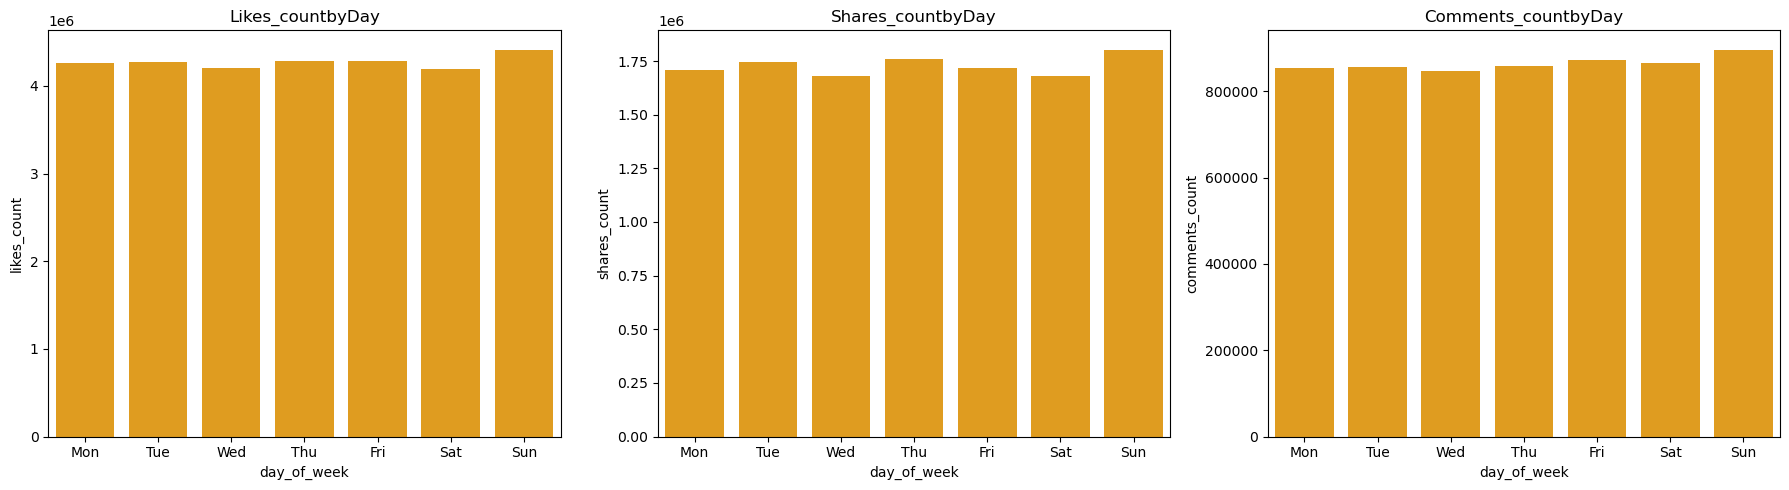

In [116]:
metrices = ['likes_count','shares_count','comments_count']

# aggregate each metric by day of week 
day_agg = df.groupby('day_of_week')[metrices].sum().reset_index()

# plotting each metrice in a single figure -> Subplots

fig, axes = plt.subplots(1,3,figsize=(18,5))
for i, m in enumerate(metrices):
    sns.barplot(ax=axes[i],data=day_agg,x='day_of_week',y=m,color='orange')
    axes[i].set_title(f'{m.capitalize()}byDay')
    axes[i].set_xticklabels(['Mon','Tue','Wed','Thu','Fri','Sat','Sun'])

plt.tight_layout()
plt.show()

### Impression vs Engagement 

In [102]:
# Find Correlation 
corr= df['impressions'].corr(df['engagement_rate'])
print('Correlation Value: ',corr)

Correlation Value:  -0.29636557830879406


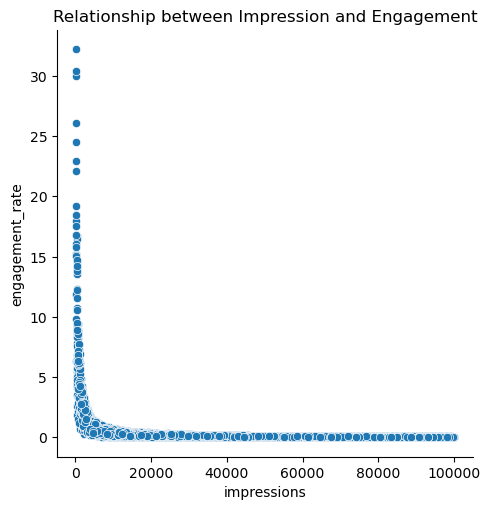

In [103]:
# Relationship between Impression and Engagement 

sns.relplot(data=df,x='impressions',y='engagement_rate',kind='scatter')
plt.title('Relationship between Impression and Engagement')
plt.show()

Higher impressions do not always lead to higher engagement, suggesting content relevance is more important than reach.

### Correlation Heatmap

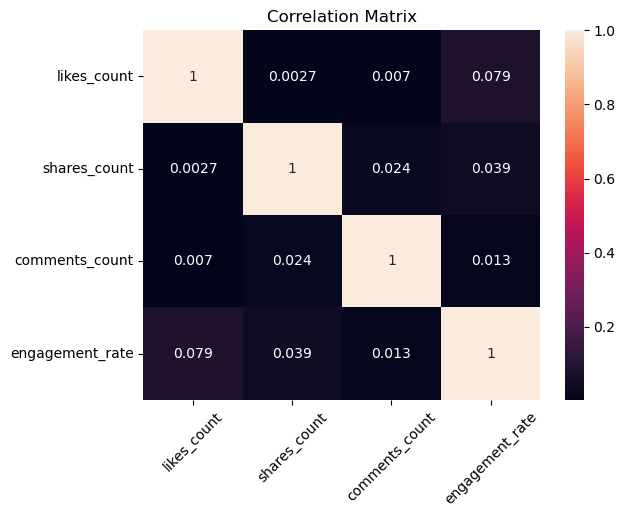

In [106]:
# Corr()
corr = df[['likes_count', 'shares_count', 'comments_count', 'engagement_rate']].corr()
# heatmap 
sns.heatmap(corr, annot=True)
plt.title("Correlation Matrix")
plt.xticks(rotation=45)
plt.show()

The Strongest correlation in the heatmap is 0.079 between engagement_rate and likes_count, meaning likes have the slightest positive effect on engagement compared with other metrices.